# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

In [278]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Let us start by importing the required libraries

In [279]:
# Installing the libraries with the specified version.
%pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user
# %pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q
#
# The above command does not work for python-3.12.10
# %pip install ipykernel numpy==1.26.4 pandas matplotlib seaborn==0.13.1 -q

In [280]:
%%python --version

Python 3.11.12


In [ ]:
%%pip --version

pip 24.1.2 from /usr/local/lib/python3.11/dist-packages/pip (python 3.11)


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [282]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [283]:
# uncomment and run the following lines for Google Colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [284]:
# Write your code here to read the data
df = pd.read_csv('/content/drive/MyDrive/AIML-Austin/workshop/food_hub/foodhub_order.csv')

In [285]:
# Write your code here to view the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [286]:
# Write your code here
df.shape

(1898, 9)

#### Observations: 1898 rows and 9 columns. The DataFrame.shape has the imformation.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [287]:
# Write your code here
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations: `df.info()` gives summary of all columns, including column names, non-null count, data types, and count of float64, int64, and object.

### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [288]:
# Write your code here
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations: No null values.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [289]:
# Write your code here
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


#### Observations: Food preparition time: min 20 minutes, average 27 minutes, max 35 minutes. The title of `food_preparation_time` should be renamed to `food_preparition_in_in_minutes` for clarity. Same for the `delivery_time`.

### **Question 5:** How many orders are not rated? [1 mark]

In [290]:
# Write the code here
df[df['rating'] == 'Not given'].shape[0]

736

#### Observations:

736 orders were not rated. The `rating` column is mixed with int64 and str. That is why this column has type of object as displayed by `df.info()`.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

<Axes: title={'center': 'Number of Order by Cuisine Type'}, xlabel='cuisine_type', ylabel='Number of Orders'>

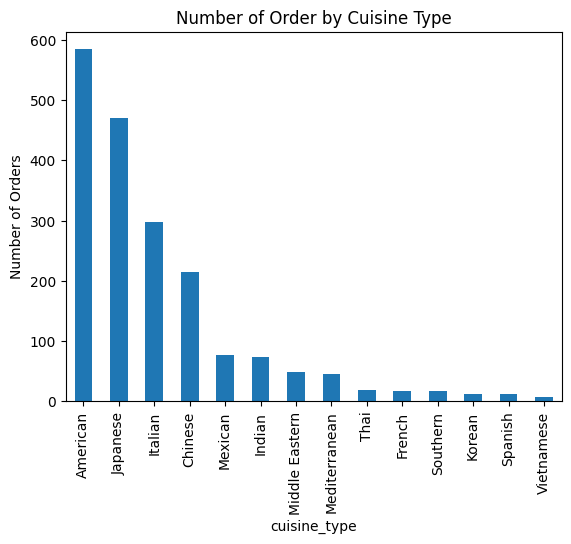

In [291]:
# Write the code here
# df.describe(include='object')
# df.value_counts()
df['cuisine_type'].value_counts().plot(kind='bar', ylabel='Number of Orders', title='Number of Order by Cuisine Type')

<Axes: title={'center': 'Number of Order by Cuisine Type'}, ylabel='Number of Orders'>

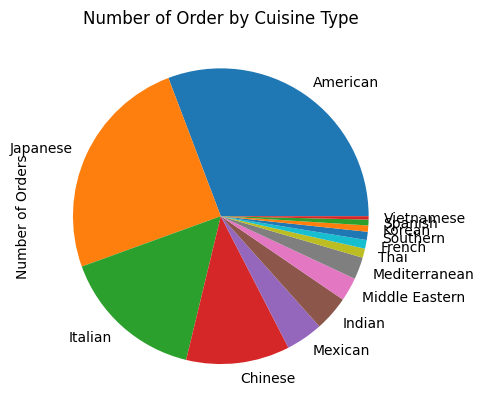

In [292]:
df['cuisine_type'].value_counts().plot(kind='pie', ylabel='Number of Orders', title='Number of Order by Cuisine Type')

In [293]:
dict = df['cuisine_type'].value_counts().to_dict()
top4 = dict.get('American') + dict.get('Japanese') + dict.get('Italian') + dict.get('Chinese')
top4_percent = top4 / df.shape[0] * 100
print(f"{top4_percent:.2f}%")

82.56%


<Axes: title={'center': 'Top Ten Most Popular Restaurants by Number of Order'}, xlabel='restaurant_name', ylabel='Number of Orders'>

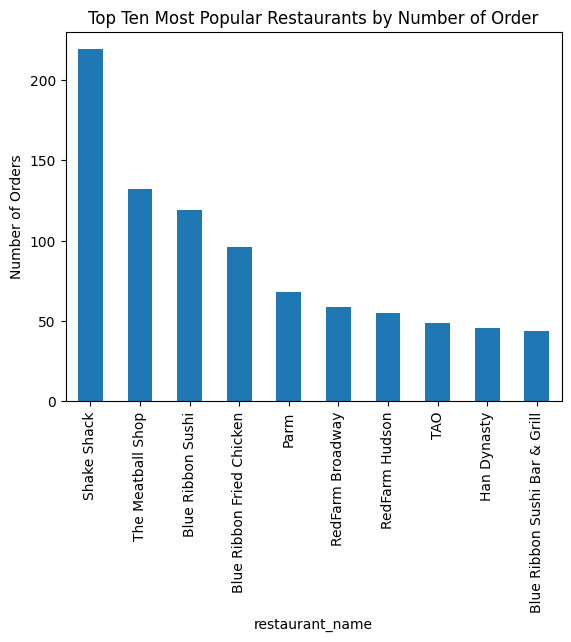

In [294]:
df['restaurant_name'].value_counts().nlargest(10).plot(kind='bar', ylabel='Number of Orders', title='Top Ten Most Popular Restaurants by Number of Order')

In [295]:
under_performing_criteria = df['restaurant_name'].value_counts() < 2
under_performing = df['restaurant_name'].value_counts()[under_performing_criteria]

print("Under performaing restaurant count (1 order per restaurant)", under_performing.shape[0])
print("Under performaing restaurant names", under_performing.keys())


Under performaing restaurant count (1 order per restaurant) 50
Under performaing restaurant names Index(['Anjappar Chettinad', 'Big Wong Restaurant _¤¾Ñ¼', 'Chote Nawab',
       'Haru Gramercy Park', 'Klong', 'Wo Hop Restaurant', 'Spice Thai',
       'Hibino', 'Woorijip', 'Samurai Mama', 'Taro Sushi', 'Pepe Giallo',
       'Kambi Ramen House', 'Posto', 'Balade', 'Chola Eclectic Indian Cuisine',
       'Dig Inn Seasonal Market', 'Gaia Italian Cafe', 'Philippe Chow',
       'The MasalaWala', 'Dos Caminos Soho', 'La Follia',
       'Cipriani Le Specialita', 'Sushi Choshi', 'Socarrat Paella Bar',
       'Alidoro', 'Rohm Thai', '67 Burger', 'Crema Restaurante',
       'Cafe de La Esquina', 'Galli Restaurant', 'Market Table',
       'Nha Trang One', 'Moonstruck on Second', 'Hampton Chutney Co.',
       'Il Bambino', 'Kori Restaurant and Bar', 'Lamarca Pasta',
       'Lucky Strike', 'Paul & Jimmy's', 'Hunan Manor', 'Coppola's East',
       'Emporio', 'Wa Jeal', 'Le Zie 2000 Trattoria', 'Rye 

In [296]:
under_performing_criteria = df['restaurant_name'].value_counts() == 2
under_performing = df['restaurant_name'].value_counts()[under_performing_criteria]

print("Under performaing restaurant count (2 orders only per restaurant)", under_performing.shape[0])

Under performaing restaurant count (2 orders only per restaurant) 23


In [297]:
# Order count per restaurant
df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


In [298]:
# Order count per cuisine type
df['cuisine_type'].value_counts()

,count
cuisine_type,
American,584
Japanese,470
Italian,298
Chinese,215
Mexican,77
Indian,73
Middle Eastern,49
Mediterranean,46
Thai,19


<Axes: title={'center': 'Number of Order by Day of the Week'}, xlabel='day_of_the_week', ylabel='Number of Orders'>

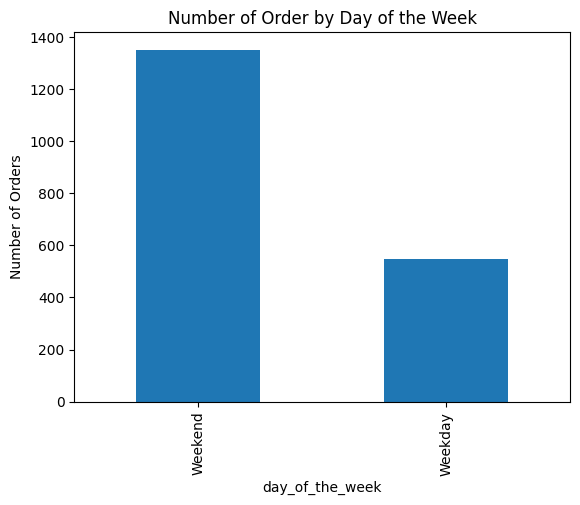

In [299]:
df['day_of_the_week'].value_counts().plot(kind='bar', ylabel='Number of Orders', title='Number of Order by Day of the Week')

Weekday order percentage: 109
Weekend order percentage: 676
{'per_weekday': [109.4], 'per_weekend': [675.5]}


<Axes: title={'center': 'Avergare Number of Orders per Day'}, ylabel='Avergare Number of Orders per Day'>

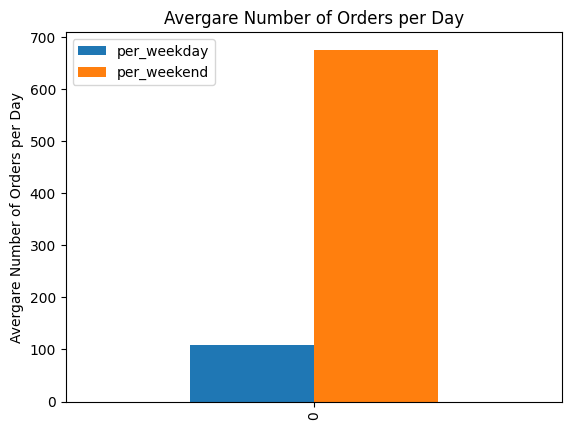

In [300]:
dict = df['day_of_the_week'].value_counts().to_dict()
per_weekday = dict.get('Weekday') / 5
per_weekend = dict.get('Weekend') / 2
print(f"Weekday order percentage: {per_weekday:.0f}")
print(f"Weekend order percentage: {per_weekend:.0f}")

orders_per_day = {'per_weekday': [per_weekday], 'per_weekend': [per_weekend]}
print(orders_per_day)
df_orders_per_day = pd.DataFrame(orders_per_day)
df_orders_per_day.plot(kind='bar', ylabel='Avergare Number of Orders per Day', title='Avergare Number of Orders per Day')

<Axes: title={'center': 'Number of Order by Rating'}, ylabel='Number of Orders'>

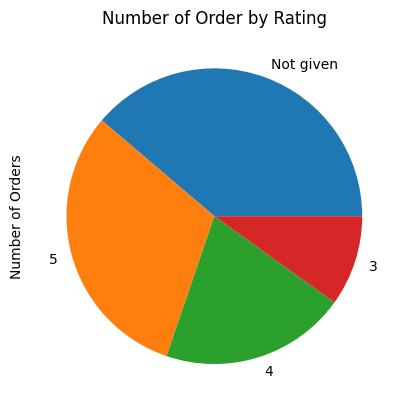

In [301]:
df['rating'].value_counts().plot(kind='pie', ylabel='Number of Orders', title='Number of Order by Rating')

<Axes: title={'center': 'Number of Order by Total Time'}, xlabel='Total Time (Prepare + Delivery) (minutes)', ylabel='Number of Orders'>

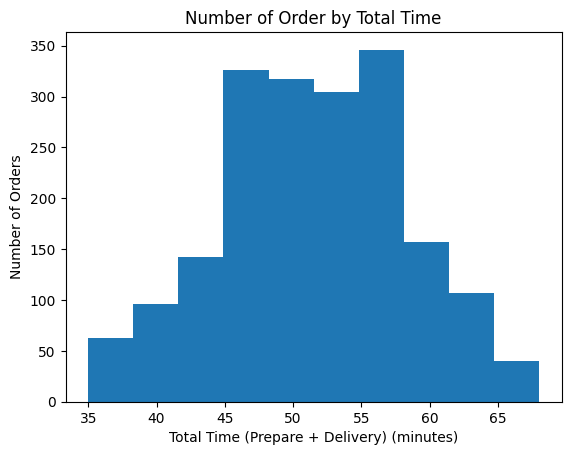

In [302]:
# Number of orders by total time
(df['food_preparation_time'] + df['delivery_time']).plot(kind='hist', ylabel='Number of Orders', xlabel='Total Time (Prepare + Delivery) (minutes)', title='Number of Order by Total Time')

<Axes: title={'center': 'Number of Order by Price'}, xlabel='Price (USD)', ylabel='Number of Orders'>

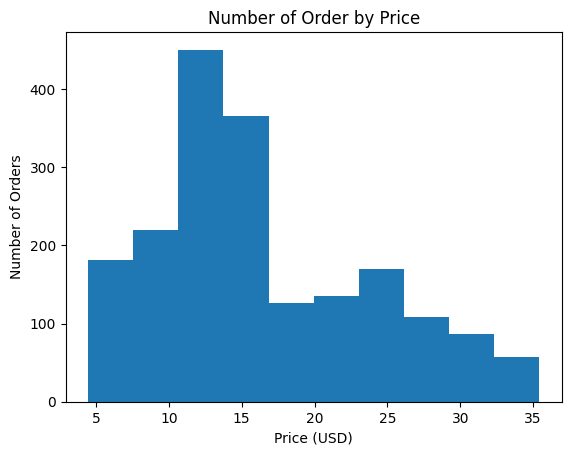

In [303]:
# Number of Oders by Price
df['cost_of_the_order'].plot(kind='hist', ylabel='Number of Orders', xlabel='Price (USD)', title='Number of Order by Price')

In [304]:
df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


In [305]:
# Average price in weekend
ave_weekend = df[df['day_of_the_week'] == 'Weekend']['cost_of_the_order'].mean()

# Average price in weekday
ave_weekday = df[df['day_of_the_week'] == 'Weekday']['cost_of_the_order'].mean()

print(f"Average price in weekend: ${ave_weekend:.2f}")
print(f"Average price in weekday: ${ave_weekday:.2f}")

Average price in weekend: $16.57
Average price in weekday: $16.31


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [306]:
# Write the code here
df['restaurant_name'].value_counts().nlargest(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:

Pandas has so many powerful functions!

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [307]:
# Write the code here
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().nlargest(1)

,count
cuisine_type,
American,415


#### Observations:

1. Filter out weekend data. 2. Call `value_counts()`. 3. Get the largest value.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [308]:
# Write the code here
ans = df[df['cost_of_the_order'] > 20].shape[0] / df.shape[0] * 100
print(f"{ans:.2f}%")

29.24%


#### Observations:

Impressed by data filtering power of pandas.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [309]:
# Write the code here
time = df['delivery_time'].mean()
print(f"{time:.2f} minutes")

24.16 minutes


#### Observations: Use `f""` formatter to make the out put more readable.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [310]:
# Write the code here
df['customer_id'].value_counts().nlargest(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations: `value_counts()` and `nlargest(n)` have been used many times in this exercise.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [311]:
# Write the code here
# Total sales by restaurants
df.groupby('restaurant_name')['cost_of_the_order'].sum().sort_values(ascending=False)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
...,...
Market Table,6.79
Wa Jeal,6.74
Big Wong Restaurant _¤¾Ñ¼,5.92


In [312]:
# Total sales by cuisin type
df.groupby('cuisine_type')['cost_of_the_order'].sum().sort_values(ascending=False)

,cost_of_the_order
cuisine_type,
American,9530.78
Japanese,7663.13
Italian,4892.77
Chinese,3505.62
Mexican,1303.85
Indian,1235.14
Middle Eastern,922.21
Mediterranean,711.84
Thai,364.95


In [313]:
# Total sales by day of the week
df.groupby('day_of_the_week')['cost_of_the_order'].sum().sort_values(ascending=False)

,cost_of_the_order
day_of_the_week,
Weekend,22392.60
Weekday,8922.22


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [314]:
# Write the code here
# Create a copy of the df to manipulate 'dating' datatype
df_copy = df.copy()
df_rated = df_copy[df_copy['rating'] != 'Not given']
df_rated.loc[:, 'rating'] = df_rated['rating'].astype(int)

# Filter
df_qualified = df_rated.groupby('restaurant_name').filter(lambda x: (x['rating'].count() > 50) and (x['rating'].mean() > 4))
print('rating count', df_qualified.groupby('restaurant_name')['rating'].count())
print('rating mean', df_qualified.groupby('restaurant_name')['rating'].mean())
print(df_qualified['restaurant_name'].unique())

rating count restaurant_name
Blue Ribbon Fried Chicken     64
Blue Ribbon Sushi             73
Shake Shack                  133
The Meatball Shop             84
Name: rating, dtype: int64
rating mean restaurant_name
Blue Ribbon Fried Chicken    4.328125
Blue Ribbon Sushi            4.219178
Shake Shack                  4.278195
The Meatball Shop            4.511905
Name: rating, dtype: object
['Blue Ribbon Fried Chicken' 'Shake Shack' 'Blue Ribbon Sushi'
 'The Meatball Shop']


#### Observations: Only four restaurant are qualified.

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [315]:
# Write the code here
df_20_dollar = df[df['cost_of_the_order'] > 20]
df_5_dollar = df[(df['cost_of_the_order'] > 5) & (df['cost_of_the_order'] <= 20)]
net_revenue = df_20_dollar['cost_of_the_order'].sum() * 0.25 + df_5_dollar['cost_of_the_order'].sum() * 0.15

print(f"${net_revenue.sum():,.2f}")

$6,166.30


#### Observations: After call filter, must call `sum()`.


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [316]:
# Write the code here
df_60_min = df[df['food_preparation_time'] + df['delivery_time'] > 60]
print(f"{df_60_min.shape[0] / df.shape[0] * 100:.2f}%")

10.54%


#### Observations: Orders takes more than 60 minutes take only 11% of all the orders.


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [317]:
# Write the code here
mean = df.groupby('day_of_the_week')['delivery_time'].mean()
print(mean)

dict = mean.to_dict()
diff = mean.get('Weekday') - mean.get('Weekend')
print(f"Weekend mean delivery time is {diff:.0f} minutes slower than weekday mean delivery time.")

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64
Weekend mean delivery time is 6 minutes slower than weekday mean delivery time.


#### Observations: Weekday delivery is 6 minutes slower.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* American, Japanese, Italian, and Chinese foods takes 83% of the total count of orders.
* 50 restaurants sold only one order.
* Most orders take 45-60 minutes from order is placed to order is received.
* Food price between `$10-$17` is the most welcome.
* Total order count in Weekend doubles that of the weekdays.
* In average, per day order count in weekend is approximated to 6 time that of weekday.
* 11% order count takes more than 60 minutes from placing the order to recieve the order.
* Average order price in weekdays `$16.31` and weekends `$16.57` are almost the same.

### Recommendations:

* 50 restaurants received only one order each, and 23 restaurant received only two order each, among 179 restaurants total. That means 41% of the restaurant get only 1-2 orders. Perhaps these restaurants should be studied for next step.
* Weekend per day orders is about 6 times of that of weekday. Need to prepare for more supply of laber and materials and space in the weekend.
* American, Japanese, Italian, Chinese, Mexican, and Indian food are the most popular food.

---